First user will only have to specify following inputs:
1. Dark Matter Type
2. Instrument they would like simulated image to be from
3. Number of simulations

In [1]:
import numpy as np
import matplotlib.pyplot as plt


#User Inputs
DM_Type = 'CDM'
Instrument = 'Roman'
Sim_Num = 1


Entire process for one simulation is stored in following function (can change to a class if thats preferable)

In [13]:
def dlu_sim(DM_Type,Instrument):
    '''Adaptive interface to simulate lensing images.'''

    #1. Configure instrument specific parameters
    def instrument_config(Instrument):
        if Instrument == 'Roman':
            from lenstronomy.SimulationAPI.ObservationConfig.Roman import Roman
            Roman_g = Roman(band='F062', psf_type='PIXEL', survey_mode='wide_area')
            Roman_r = Roman(band='F106', psf_type='PIXEL', survey_mode='wide_area')
            Roman_i = Roman(band='F184', psf_type='PIXEL', survey_mode='wide_area')
            roman = [Roman_g, Roman_r, Roman_i]
            print('Roman config set!')
            return roman
        
        elif Instrument == 'LSST':
            from lenstronomy.SimulationAPI.ObservationConfig.LSST import LSST
            LSST_g = LSST(band='g', psf_type='GAUSSIAN', coadd_years=10)
            LSST_r = LSST(band='r', psf_type='GAUSSIAN', coadd_years=10)
            LSST_i = LSST(band='i', psf_type='GAUSSIAN', coadd_years=10)
            lsst = [LSST_g, LSST_r, LSST_i]
            print('LSST config set!')
            return lsst
        
        elif Instrument == 'DES':
            from lenstronomy.SimulationAPI.ObservationConfig.DES import DES
            DES_g = DES(band = 'g',psf_type='GAUSSIAN',coadd_years=3)
            DES_r = DES(band = 'r',psf_type='GAUSSIAN',coadd_years=3)
            DES_i = DES(band = 'i',psf_type='GAUSSIAN',coadd_years=3)
            des = [DES_g,DES_r,DES_i]
            print('DES config set!')
            return des
    
    instrument_param = instrument_config(Instrument=Instrument)
            
    #2.Data Extraction
    import h5py
    from scipy.ndimage import gaussian_filter
    import numpy as np
    def extraction():
        '''Sample GalaxiesML Dataset for sources and deflectors.'''
        data_file = '5x127x127_testing_with_morphology.hdf5'
        with h5py.File(data_file, 'r') as file:
            
            #Deflector:
            idd = np.random.randint(len(file['image']))
            while file['specz_redshift'][idd] > 1.0:
                print(str(idd)+ " does NOT work for deflector!")
                idd = np.random.randint((len(file['image'])))
            print(str(idd)+ " works!")
            mag_d = file['g_cmodel_mag'][idd]
            zdeflector = np.round(file['specz_redshift'][idd],2)
            
            
            #Source:
            ids = np.random.randint(len(file['image']))
            while file['specz_redshift'][ids] < (zdeflector + 0.25) or file['specz_redshift'][ids] > 4.0:  #SEEMS TO BE A LIMIT ON HOW CLOSER SOURCE AND DEFLECTOR CAN BE WHEN USING PYHALO (R ERROR). WHAT IS CLOSEST THEY CAN BE?
                print(str(ids)+ " does NOT work for source!")
                ids = np.random.randint((len(file['image'])))    
            print(str(ids)+ " works!")
            mag_s = file['g_cmodel_mag'][ids]
            zsource = np.round(file['specz_redshift'][ids],2)
        

            redshifts = [zdeflector,zsource]
            return mag_s,mag_d,redshifts

    source_mag,deflector_mag,redshifts = extraction()  

    print('Lens and Source chosen!')
    #3. Construct host halo, sub halos, and field halos 
    import pyHalo
    import pyHalo.preset_models
    from astropy import units as u
    from astropy.constants import G, c, M_sun

    def Host_mass(mean = 13, sigma =1.0):
        '''Samples log of host mass from normal distribution'''
        M_host = np.random.normal(loc = mean,scale = sigma,size =1)
        return M_host[0]

    def Host_slope(gammaL = 1.9, gammaH = 2.2):
        '''Samples host halos log slope between lower and upper bounds from Gilman et al. 2022'''
        return np.random.uniform(gammaL,gammaH,1)
    
    def CDM_constructor(zsource, zlens, M_host, Host_gamma):
        '''This function constructs a lens (host halo, sub halo, LOS halos, and lens galaxy) under the assumption of CDM'''
        arcsec_opening_angle = 10

        #First, use Pyhalo to create subhalo realization
        Subhalo_constructor= pyHalo.preset_models.preset_model_from_name('CDM')
        Subhalo_realization = Subhalo_constructor(z_lens=zlens,z_source=zsource,log_m_host=M_host,cone_opening_angle_arcsec=arcsec_opening_angle) 

        #Extract both lensing quantities from subhalo realization (reshifts, lensing models, lensing kwargs) and the cosmology instance from source to observer
        Sub_model_list, Sub_redshift_array, Sub_kwargs, _ = Subhalo_realization.lensing_quantities()
        cosmology = Subhalo_realization.astropy_instance

        #Calc Einstein radius
        def mass_to_radius(Mass,redshift_src,redshift_def):
            M_Halo = 10**Mass * M_sun
            rad_to_arcsec = 206265

            DL = cosmology.luminosity_distance(redshift_def).to(u.m)
            DS = cosmology.luminosity_distance(redshift_src).to(u.m)
            DLS = DS - DL

            # Einstein radius
            theta = np.sqrt(4 * G * M_Halo/c**2 * DLS/(DL*DS))

            # Return radius in arcsecods
            radius_arcsec = theta * rad_to_arcsec

            return radius_arcsec.value

        theta_E = mass_to_radius(M_host,zsource,zdeflector)


        #Host halo
        Host_halo = 'EPL'
        Host_kwargs = {'theta_E':theta_E,'gamma':Host_gamma,'e1':0.4,'e2':-0.1,'center_x':0.0, 'center_y':0.0} 

        #External shear
        External_shear = 'SHEAR'
        Shear_kwargs = {'gamma1':0.03,'gamma2':0.01,'ra_0': 0.0, 'dec_0': 0.0} 

        #Macrolens
        Macro_model_list = [Host_halo,External_shear]
        Macro_kwargs_list = [Host_kwargs,Shear_kwargs]
        Macro_redshift_list = [zlens,zlens]

        #Combine macro-model with substructure 
        lens_model_list = Macro_model_list + Sub_model_list
        lens_kwargs_list = Macro_kwargs_list + Sub_kwargs
        lens_redshift_list = Macro_redshift_list + list(Sub_redshift_array)

        return lens_model_list,lens_kwargs_list,lens_redshift_list,cosmology,Macro_model_list, Macro_kwargs_list, Macro_redshift_list, arcsec_opening_angle

    def Axion_constructor(zsource, zlens, M_host, Host_gamma):
        '''This function constructs a lens (host halo, sub halo, LOS halos, and lens galaxy) under the assumption of axionic dark matter'''
        
        M_axion = np.random.uniform(-23,-19,1)
        flucs_shape='ring'
        arcsec_opening_angle = 10
        flucs_args={'angle': 0.0, 'rmin': 0.9, 'rmax': 1.1}

        #First, use Pyhalo to create subhalo realization
        Subhalo_constructor= pyHalo.preset_models.preset_model_from_name('ULDM')
        Subhalo_realization = Subhalo_constructor(z_lens=zlens,z_source=zsource,log10_m_uldm = M_axion ,flucs_shape=flucs_shape,flucs_args=flucs_args , log_m_host=M_host,cone_opening_angle_arcsec=arcsec_opening_angle) 

        #Extract both lensing quantities from subhalo realization (reshifts, lensing models, lensing kwargs) and the cosmology instance from source to observer
        Sub_model_list, Sub_redshift_array, Sub_kwargs, _ = Subhalo_realization.lensing_quantities()
        cosmology = Subhalo_realization.astropy_instance

        #Calc Einstein radius
        def mass_to_radius(Mass,redshift_src,redshift_def):
            M_Halo = 10**Mass * M_sun
            rad_to_arcsec = 206265

            DL = cosmology.luminosity_distance(redshift_def).to(u.m)
            DS = cosmology.luminosity_distance(redshift_src).to(u.m)
            DLS = DS - DL

            # Einstein radius
            theta = np.sqrt(4 * G * M_Halo/c**2 * DLS/(DL*DS))

            # Return radius in arcsecods
            radius_arcsec = theta * rad_to_arcsec

            return radius_arcsec.value

        theta_E = mass_to_radius(M_host,zsource,zdeflector)

        #Host halo
        Host_halo = 'EPL'
        Host_kwargs = {'theta_E':theta_E,'gamma': Host_gamma,'e1':0.4,'e2':-0.1,'center_x':0.0, 'center_y':0.0} 

        #External shear
        External_shear = 'SHEAR'
        Shear_kwargs = {'gamma1':0.03,'gamma2':0.01,'ra_0': 0, 'dec_0': 0} 

        #Macrolens
        Macro_model_list = [Host_halo,External_shear]
        Macro_kwargs_list = [Host_kwargs,Shear_kwargs]
        Macro_redshift_list = [zlens,zlens]

        #Combine macro-model with substructure 
        lens_model_list = Macro_model_list + Sub_model_list
        lens_kwargs_list = Macro_kwargs_list + Sub_kwargs
        lens_redshift_list = Macro_redshift_list + list(Sub_redshift_array)

        return lens_model_list,lens_kwargs_list,lens_redshift_list,cosmology,Macro_model_list, Macro_kwargs_list, Macro_redshift_list, arcsec_opening_angle, M_axion, flucs_shape,flucs_args
        
    def WDM_constructor(zsource, zlens, M_host, Host_gamma):
        '''This function constructs a lens (host halo, sub halo, LOS halos, and lens galaxy) under the assumption of WDM'''
        
        log_mc = 7.0
        arcsec_opening_angle = 10

        #First, use Pyhalo to create subhalo realization
        Subhalo_constructor= pyHalo.preset_models.preset_model_from_name('WDM')
        Subhalo_realization = Subhalo_constructor(z_lens=zlens,z_source=zsource,log_mc=log_mc,log_m_host=M_host,cone_opening_angle_arcsec=arcsec_opening_angle) 

        #Extract both lensing quantities from subhalo realization (reshifts, lensing models, lensing kwargs) and the cosmology instance from source to observer
        Sub_model_list, Sub_redshift_array, Sub_kwargs, _ = Subhalo_realization.lensing_quantities()
        cosmology = Subhalo_realization.astropy_instance

        #Calc Einstein radius
        def mass_to_radius(Mass,redshift_src,redshift_def):
            M_Halo = 10**Mass * M_sun
            rad_to_arcsec = 206265

            DL = cosmology.luminosity_distance(redshift_def).to(u.m)
            DS = cosmology.luminosity_distance(redshift_src).to(u.m)
            DLS = DS - DL

            # Einstein radius
            theta = np.sqrt(4 * G * M_Halo/c**2 * DLS/(DL*DS))

            # Return radius in arcsecods
            radius_arcsec = theta * rad_to_arcsec

            return radius_arcsec.value

        theta_E = mass_to_radius(M_host,zsource,zdeflector)

        #Host Halo
        Host_halo = 'EPL'
        Host_kwargs = {'theta_E':theta_E,'gamma': Host_gamma,'e1':0.4,'e2':-0.1,'center_x':0.0, 'center_y':0.0} 

        #External shear
        External_shear = 'SHEAR'
        Shear_kwargs = {'gamma1':0.03,'gamma2':0.01,'ra_0': 0, 'dec_0': 0} 

        #Macrolens
        Macro_model_list = [Host_halo,External_shear]
        Macro_kwargs_list = [Host_kwargs,Shear_kwargs]
        Macro_redshift_list = [zlens,zlens]

        #Combine macro-model with substructure 
        lens_model_list = Macro_model_list + Sub_model_list
        lens_kwargs_list = Macro_kwargs_list + Sub_kwargs
        lens_redshift_list = Macro_redshift_list + list(Sub_redshift_array)

        return lens_model_list,lens_kwargs_list,lens_redshift_list,cosmology, Macro_model_list, Macro_kwargs_list, Macro_redshift_list, arcsec_opening_angle,log_mc

    def SIDM_constructor(zsource, zlens, M_host, Host_gamma):
        '''This function constructs a lens (host halo, sub halo, LOS halos, and lens galaxy) under the assumption of SIDM'''
        
        mass_ranges_subhalos=[[6.0, 7.0], [7.0, 8.0], [8.0, 9.0], [9.0, 10.0]]
        mass_ranges_field_halos=[[6.0, 7.5], [7.5, 8.5], [8.5, 10.0]]
        probabilities_subhalos=[0.9, 0.7, 0.5, 0.2]
        probabilities_field_halos=[0.3, 0.2, 0.1]
        cone_opening_angle_arcsec=10


        #First, use Pyhalo to create subhalo realization
        Subhalo_constructor= pyHalo.preset_models.preset_model_from_name('SIDM_core_collapse')
        Subhalo_realization = Subhalo_constructor(z_lens=zlens,z_source=zsource,mass_ranges_subhalos=mass_ranges_subhalos,mass_ranges_field_halos=mass_ranges_field_halos,probabilities_subhalos=probabilities_subhalos,probabilities_field_halos=probabilities_field_halos,log_m_host=M_host,cone_opening_angle_arcsec=cone_opening_angle_arcsec) 

        #Extract both lensing quantities from subhalo realization (reshifts, lensing models, lensing kwargs) and the cosmology instance from source to observer
        Sub_model_list, Sub_redshift_array, Sub_kwargs, _ = Subhalo_realization.lensing_quantities()
        cosmology = Subhalo_realization.astropy_instance

        #Calc Einstein radius
        def mass_to_radius(Mass,redshift_src,redshift_def):
            M_Halo = 10**Mass * M_sun
            rad_to_arcsec = 206265

            DL = cosmology.luminosity_distance(redshift_def).to(u.m)
            DS = cosmology.luminosity_distance(redshift_src).to(u.m)
            DLS = DS - DL

            # Einstein radius
            theta = np.sqrt(4 * G * M_Halo/c**2 * DLS/(DL*DS))

            # Return radius in arcsecods
            radius_arcsec = theta * rad_to_arcsec

            return radius_arcsec.value

        theta_E = mass_to_radius(M_host,zsource,zdeflector)

        #Host Halo
        Host_halo = 'EPL'
        Host_kwargs = {'theta_E':theta_E,'gamma': Host_gamma,'e1':0.4,'e2':-0.1,'center_x':0.0, 'center_y':0.0} 

        #External shear
        External_shear = 'SHEAR'
        Shear_kwargs = {'gamma1':0.03,'gamma2':0.01,'ra_0': 0.0, 'dec_0': 0.0} 

        #Macrolens
        Macro_model_list = [Host_halo,External_shear]
        Macro_kwargs_list = [Host_kwargs,Shear_kwargs]
        Macro_redshift_list = [zlens,zlens]

        #Combine macro-model with substructure 
        lens_model_list = Macro_model_list + Sub_model_list
        lens_kwargs_list = Macro_kwargs_list + Sub_kwargs
        lens_redshift_list = Macro_redshift_list + list(Sub_redshift_array)

        return lens_model_list,lens_kwargs_list,lens_redshift_list,cosmology, Macro_model_list, Macro_kwargs_list, Macro_redshift_list, mass_ranges_subhalos, mass_ranges_field_halos, probabilities_subhalos, probabilities_field_halos, cone_opening_angle_arcsec

    m_Host = Host_mass()
    slope_Host = Host_slope()
    zdeflector = redshifts[0]
    zsource = redshifts[1]

    
    if DM_Type == 'CDM':
        lens_model_list,lens_kwargs_list,lens_redshift_list,cosmology,Macro_model_list, Macro_kwargs_list, Macro_redshift_list,arcsecond_opening_angle=CDM_constructor(zsource=zsource,zlens=zdeflector,M_host=m_Host,Host_gamma=slope_Host)

    elif DM_Type == 'WDM':
        lens_model_list,lens_kwargs_list,lens_redshift_list,cosmology,Macro_model_list, Macro_kwargs_list, Macro_redshift_list, log_mc, arcsecond_opening_angle =WDM_constructor(zsource=zsource,zlens=zdeflector,M_host=m_Host,Host_gamma=slope_Host)
    
    elif DM_Type == 'SIDM':
        lens_model_list,lens_kwargs_list,lens_redshift_list,cosmology,Macro_model_list, Macro_kwargs_list, Macro_redshift_list, mass_ranges_subhalos, mass_ranges_field_halos, probabilities_subhalos, probabilities_field_halos, arcsecond_opening_angle=SIDM_constructor(zsource=zsource,zlens=zdeflector,M_host=m_Host,Host_gamma=slope_Host)

    elif DM_Type == 'Axion':
        lens_model_list,lens_kwargs_list,lens_redshift_list,cosmology,Macro_model_list, Macro_kwargs_list, Macro_redshift_list,M_axion,arcsecond_opening_angle=Axion_constructor(zsource=zsource,zlens=zdeflector,M_host=m_Host,Host_gamma=slope_Host,M_axion=M_axion),M_axion


    print('Substructure constructed!')
    
    #4. Consolidate lens and source models and finalize kwargs
    kwargs_model = {'lens_model_list': lens_model_list,  
                'lens_redshift_list': lens_redshift_list,
                'lens_light_model_list': ['SERSIC'], 
                'source_light_model_list': ['SERSIC'], 
                'z_source':zsource,
                'cosmo': cosmology}
    
    source_pos_xx,source_pos_yy = np.random.uniform(-Macro_kwargs_list[0]['theta_E']*0.3, Macro_kwargs_list[0]['theta_E']*0.3), np.random.uniform(-Macro_kwargs_list[0]['theta_E']*0.3, Macro_kwargs_list[0]['theta_E']*0.3)
    #source_pos_xx,source_pos_yy = 0.0,0.0

    
    band_g = instrument_param[0]
    kwargs_g_band = band_g.kwargs_single_band()

    def kwargs_light_mag(posxx,posyy):
        '''Returns kwargs_single_band values for g,r,and i while taking into account intrument of simulated image.'''
        # source light
        kwargs_source_mag = [{'amp': 1000, 'R_sersic': 2.0, 'n_sersic': 1.5, 'center_x': posxx, 'center_y': posyy}]
        # lens light
        kwargs_lens_light_mag = [{'amp': 100, 'R_sersic': 1.0, 'n_sersic': 2.5, 'center_x': 0.0, 'center_y': 0.0}]

        return kwargs_lens_light_mag, kwargs_source_mag

    kwargs_lens_light_mag, kwargs_source_mag = kwargs_light_mag(source_pos_xx,source_pos_yy)

    print('Ready to simulate!')

    #5. Simulate Image and Add Noise
    from lenstronomy.SimulationAPI.sim_api import SimAPI
    import lenstronomy.Plots.plot_util as plot_util

    kwargs_numerics = {'point_source_supersampling_factor': 1}
    
    def simulate_rgb(kwargs_numerics,band_kwargs,lens_light_kwargs,source_light_kwargs,lens_nonlight_kwargs):
        numpix = 64

        sim_g = SimAPI(numpix=numpix, kwargs_single_band=band_kwargs, kwargs_model=kwargs_model)

        imSim_g = sim_g.image_model_class(kwargs_numerics)
        
        #kwargs_lens_light, kwargs_source,_ = sim_g.magnitude2amplitude(lens_light_kwargs, source_light_kwargs)
       
        image = imSim_g.image(lens_nonlight_kwargs, source_light_kwargs, lens_light_kwargs,point_source_add=False,lens_light_add=True)
       
        image += sim_g.noise_for_model(model=image)
      
        return image
    
    img= simulate_rgb(kwargs_numerics=kwargs_numerics,band_kwargs=kwargs_g_band,lens_light_kwargs=kwargs_lens_light_mag,source_light_kwargs=kwargs_source_mag,lens_nonlight_kwargs=lens_kwargs_list)
    
    if DM_Type == 'CDM':
        instr_dict = {'name': Instrument, 'pixel_scale': kwargs_g_band['pixel_scale'],'psf':kwargs_g_band['psf_type']}
        source_dict = {'zsource':zsource,'mag_src': source_mag,'center':np.array([source_pos_xx,source_pos_yy])}
        ext_shear_dict = {'gamma_1':Macro_kwargs_list[1]['gamma1'], 'gamma_2':Macro_kwargs_list[1]['gamma2']}
        sub_defl_dict = {'arcsec_opening':arcsecond_opening_angle}
        host_defl_dict = {'zdeflector':zdeflector,'host_mass':Host_mass,'host_slope':Host_slope,'theta_E':Macro_kwargs_list[0]['theta_E'],'ellipticity':np.array([Macro_kwargs_list[0]['e1'],Macro_kwargs_list[0]['e2']])}
        defl_dict = {'subhalos':sub_defl_dict,'host':host_defl_dict,'ext_shear':ext_shear_dict}
        output = {'image': img, 'deflector':defl_dict,'source':source_dict,'instrument':instr_dict}

    if DM_Type == 'Axion':
        instr_dict = {'name': Instrument, 'pixel_scale': kwargs_g_band['pixel_scale'],'psf':kwargs_g_band['psf_type']}
        source_dict = {'zsource':zsource,'mag_src': source_mag,'center':np.array([source_pos_xx,source_pos_yy])}
        ext_shear_dict = {'gamma_1':Macro_kwargs_list[1]['gamma1'], 'gamma_2':Macro_kwargs_list[1]['gamma2']}
        sub_defl_dict = {'arcsec_opening':arcsecond_opening_angle, 'axion_mass':M_axion}
        host_defl_dict = {'zdeflector':zdeflector,'host_mass':Host_mass,'host_slope':Host_slope,'theta_E':Macro_kwargs_list[0]['theta_E'],'ellipticity':np.array([Macro_kwargs_list[0]['e1'],Macro_kwargs_list[0]['e2']])}
        defl_dict = {'subhalos':sub_defl_dict,'host':host_defl_dict,'ext_shear':ext_shear_dict}
        output = {'image': img, 'deflector':defl_dict,'source':source_dict,'instrument':instr_dict}
    
    if DM_Type == 'WDM':
        instr_dict = {'name': Instrument, 'pixel_scale': kwargs_g_band['pixel_scale'],'psf':kwargs_g_band['psf_type']}
        source_dict = {'zsource':zsource,'mag_src': source_mag,'center':np.array([source_pos_xx,source_pos_yy])}
        ext_shear_dict = {'gamma_1':Macro_kwargs_list[1]['gamma1'], 'gamma_2':Macro_kwargs_list[1]['gamma2']}
        sub_defl_dict = {'arcsec_opening':arcsecond_opening_angle,'supressed_mass':log_mc}
        host_defl_dict = {'zdeflector':zdeflector,'host_mass':Host_mass,'host_slope':Host_slope,'theta_E':Macro_kwargs_list[0]['theta_E'],'ellipticity':np.array([Macro_kwargs_list[0]['e1'],Macro_kwargs_list[0]['e2']])}
        defl_dict = {'subhalos':sub_defl_dict,'host':host_defl_dict,'ext_shear':ext_shear_dict}
        output = {'image': img, 'deflector':defl_dict,'source':source_dict,'instrument':instr_dict}

    if DM_Type == 'SIDM':
        instr_dict = {'name': Instrument, 'pixel_scale': kwargs_g_band['pixel_scale'],'psf':kwargs_g_band['psf_type']}
        source_dict = {'zsource':zsource,'mag_src': source_mag,'center':np.array([source_pos_xx,source_pos_yy])}
        ext_shear_dict = {'gamma_1':Macro_kwargs_list[1]['gamma1'], 'gamma_2':Macro_kwargs_list[1]['gamma2']}
        sub_defl_dict = {'arcsec_opening':arcsecond_opening_angle,'subhalo_mass_ranges':mass_ranges_subhalos,'field_halos_mass_ranges':mass_ranges_field_halos,'prob_subhalo':probabilities_subhalos,'prob_field_halo':probabilities_field_halos}
        host_defl_dict = {'zdeflector':zdeflector,'host_mass':Host_mass,'host_slope':Host_slope,'theta_E':Macro_kwargs_list[0]['theta_E'],'ellipticity':np.array([Macro_kwargs_list[0]['e1'],Macro_kwargs_list[0]['e2']])}
        defl_dict = {'subhalos':sub_defl_dict,'host':host_defl_dict,'ext_shear':ext_shear_dict}
        output = {'image': img, 'deflector':defl_dict,'source':source_dict,'instrument':instr_dict}
    print('Done!')
    return output

Right now multiple simulations can be run using a simple for loop. 
Outputs have the following structure:

OUTPUT = {'image':SIMULATED IMAGE, 
'deflector':ALL RELEVANT DEFLECTOR PARAMS,
'source':ALL RELEVANT SOURCE PARAMS,
'instrument': ALL RELEVANT INSTRUMENT PARAMS}


In [16]:
Sim_Outputs = np.array([],dtype=object)
for i in range(0,Sim_Num):
    Simulation = dlu_sim(DM_Type,Instrument)
    Sim_Outputs = np.append(Sim_Outputs,Simulation)
    print(f'Simulation {i + 1} of {Sim_Num} complete!')

Roman config set!
21338 works!
29824 does NOT work for source!
11495 does NOT work for source!
13090 does NOT work for source!
2227 works!
Lens and Source chosen!
Substructure constructed!
Ready to simulate!
Done!
Simulation 1 of 1 complete!


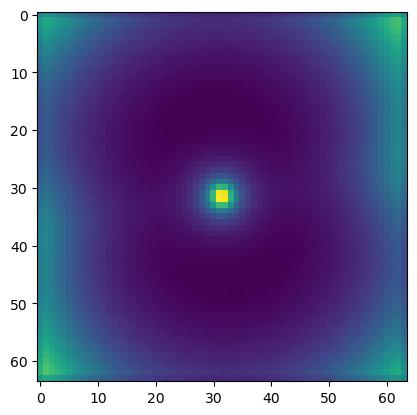

In [18]:
plt.imshow(Sim_Outputs[0]['image'])

In [20]:
Sim_Outputs[0]['deflector']['host']['theta_E']

6.060770673466886